# IN5437 — Assignment 1
## Question 8: Salt-and-Pepper Noise Removal

**Name:** Benjamine  
**Index:** 258762A

Apply two smoothing filters to an image corrupted with salt-and-pepper noise:
- (a) Gaussian smoothing
- (b) Median filtering

Compare the effectiveness of each for this type of noise.

In [13]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

### Load the noisy image

Shape: (494, 438) | Min: 0 | Max: 255


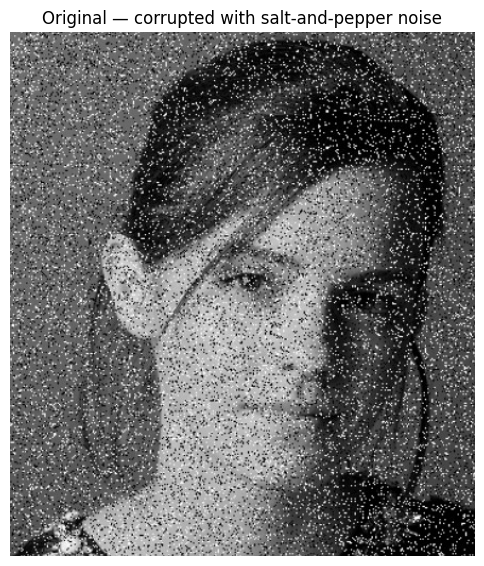

In [14]:
q8_im = cv.imread('../images/salt_pepper.jpg', cv.IMREAD_GRAYSCALE)
assert q8_im is not None, "File could not be read. Check the path."

print('Shape:', q8_im.shape, '| Min:', q8_im.min(), '| Max:', q8_im.max())

plt.figure(figsize=(6, 8))
plt.imshow(q8_im, cmap='gray', vmin=0, vmax=255)
plt.title('Original — corrupted with salt-and-pepper noise')
plt.axis('off')
plt.show()

### Question 08.a: Gaussian smoothing

Use `cv.GaussianBlur()` with a 5×5 kernel and σ = 1.

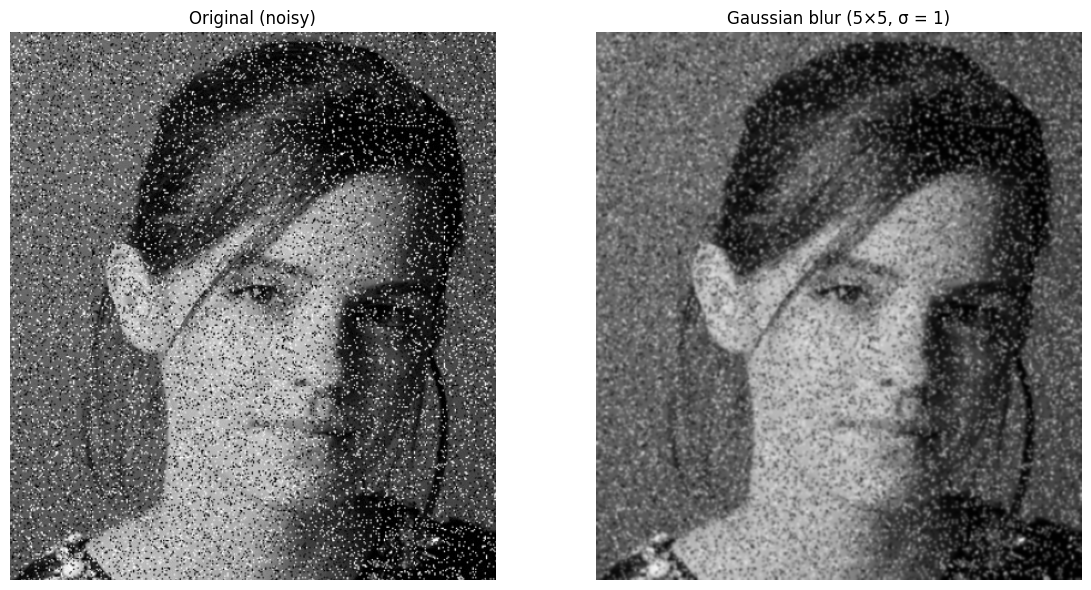

In [15]:
# Gaussian blur — 5x5 kernel, sigma = 1
g_8a = cv.GaussianBlur(q8_im, (5, 5), 1)

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(q8_im, cmap='gray', vmin=0, vmax=255); ax[0].set_title('Original (noisy)'); ax[0].axis('off')
ax[1].imshow(g_8a,  cmap='gray', vmin=0, vmax=255); ax[1].set_title('Gaussian blur (5×5, σ = 1)'); ax[1].axis('off')
plt.tight_layout()
plt.show()

### Question 08.b: Median filtering

Use `cv.medianBlur()` with a 5×5 kernel.

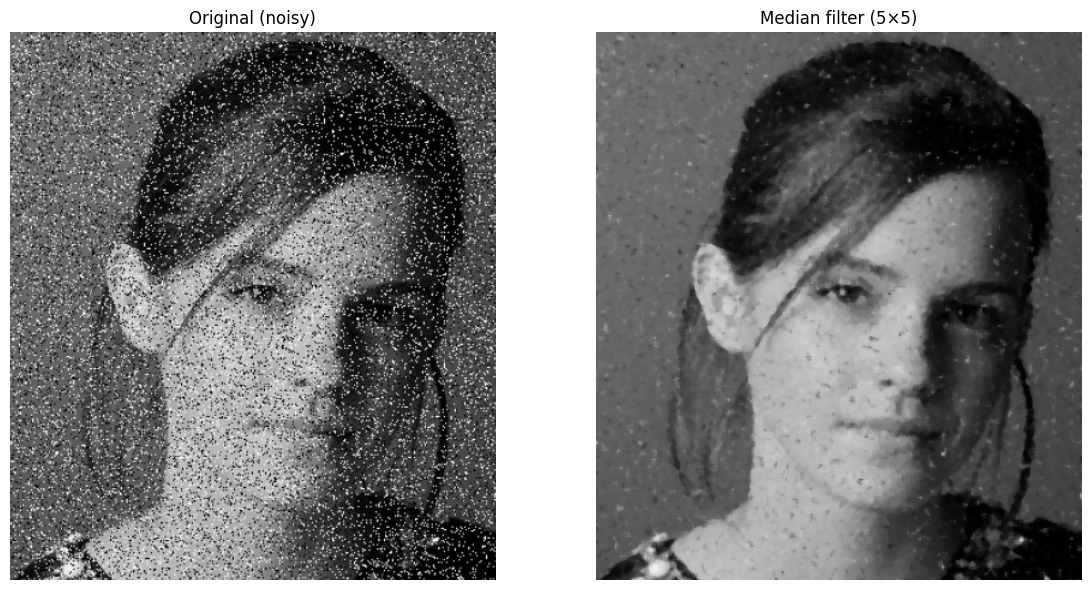

In [16]:
# Median filter — 5x5 kernel
g_8b = cv.medianBlur(q8_im, 5)

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(q8_im, cmap='gray', vmin=0, vmax=255); ax[0].set_title('Original (noisy)'); ax[0].axis('off')
ax[1].imshow(g_8b,  cmap='gray', vmin=0, vmax=255); ax[1].set_title('Median filter (5×5)'); ax[1].axis('off')
plt.tight_layout()
plt.show()

### Side-by-side comparison: Gaussian vs Median

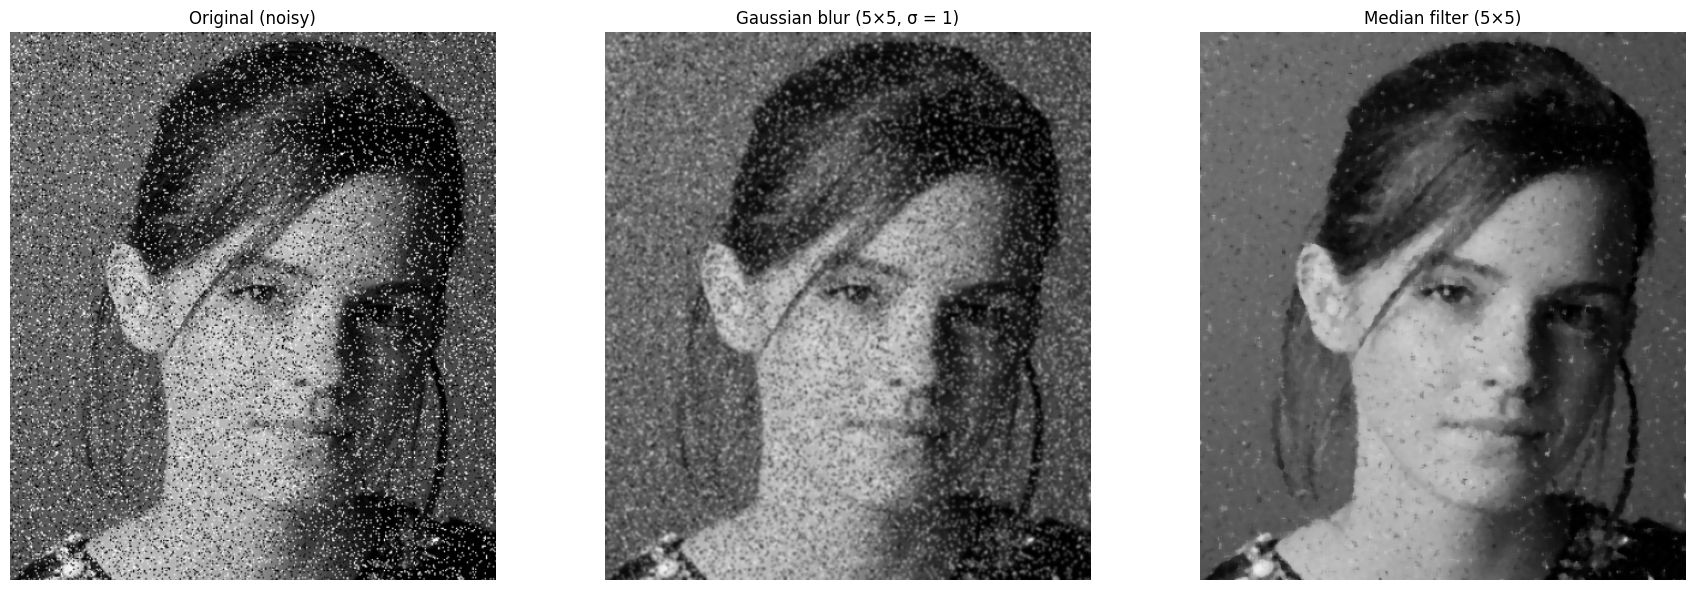

In [17]:
fig, ax = plt.subplots(1, 3, figsize=(18, 6))
ax[0].imshow(q8_im, cmap='gray', vmin=0, vmax=255); ax[0].set_title('Original (noisy)');         ax[0].axis('off')
ax[1].imshow(g_8a,  cmap='gray', vmin=0, vmax=255); ax[1].set_title('Gaussian blur (5×5, σ = 1)'); ax[1].axis('off')
ax[2].imshow(g_8b,  cmap='gray', vmin=0, vmax=255); ax[2].set_title('Median filter (5×5)');       ax[2].axis('off')
plt.tight_layout()
plt.show()

### Observation

- **Gaussian blur** averages neighboring pixels linearly. Salt (255) and pepper (0) values get spread into gray smudges across the image — the noise is *softened* but not removed, and edges become blurry.

- **Median filter** replaces each pixel with the median of its neighborhood. Since salt-and-pepper pixels are extreme outliers, they are automatically excluded when the median is computed, so the noise is removed cleanly while edges are preserved.

**Conclusion:** Median filtering is the correct choice for salt-and-pepper (impulse) noise. Gaussian blur is better suited for Gaussian (random additive) noise.